In [21]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pyprojroot import here

In [22]:
RAW_DATA_DIR = here() / "data" / "raw"
INTERIM_DATA_DIR = here() / "data" / "interim"
PROCESSED_DATA_DIR = here() / "data" / "processed"
RESULTS_DATA_DIR = here() / "results"

In [23]:
gdf = gpd.read_file(RAW_DATA_DIR/'geography/municipalities/00mun.shp')
df_fuzzy = pd.read_csv(PROCESSED_DATA_DIR/"RELMS_index.csv", encoding="utf-8")

In [24]:
gdf['CVEGEO'] = gdf['CVEGEO'].astype(str).str.zfill(5)
df_fuzzy['CVEGEO'] = df_fuzzy['CVEGEO'].astype(str).str.zfill(5)

gdf = gdf.merge(df_fuzzy[['CVEGEO', 'RELMS_index', 'idx_resources', 'idx_energy', 'idx_logistics', 'idx_market', 'idx_security']], on='CVEGEO', how='left')


In [25]:
plot_columns = ['RELMS_index',
       'idx_resources', 'idx_energy', 'idx_logistics', 'idx_market',
       'idx_security']

colors = ['Greens', 'plasma', 'Blues', 'Reds', 'Oranges', 'Greys']
i=0

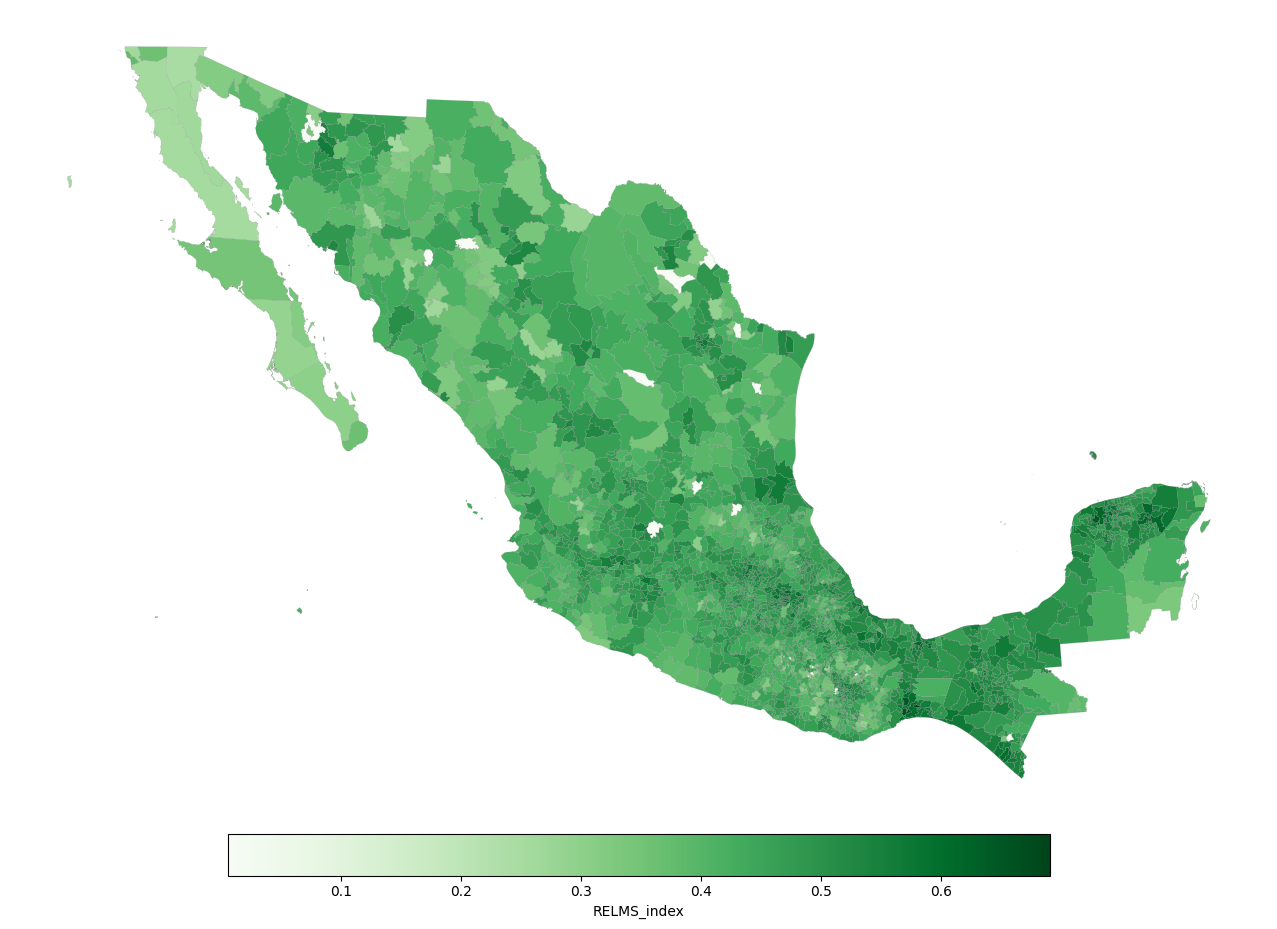

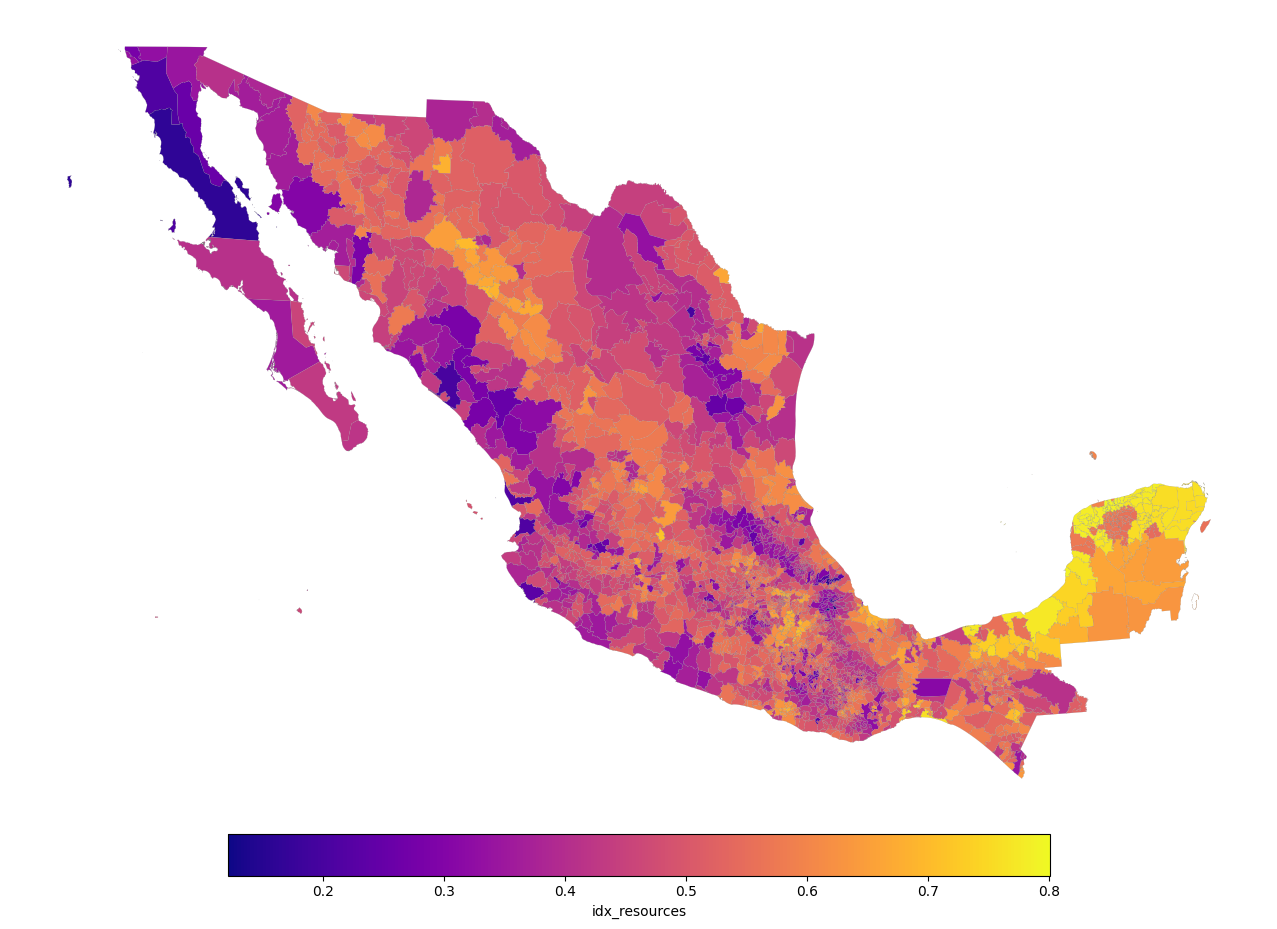

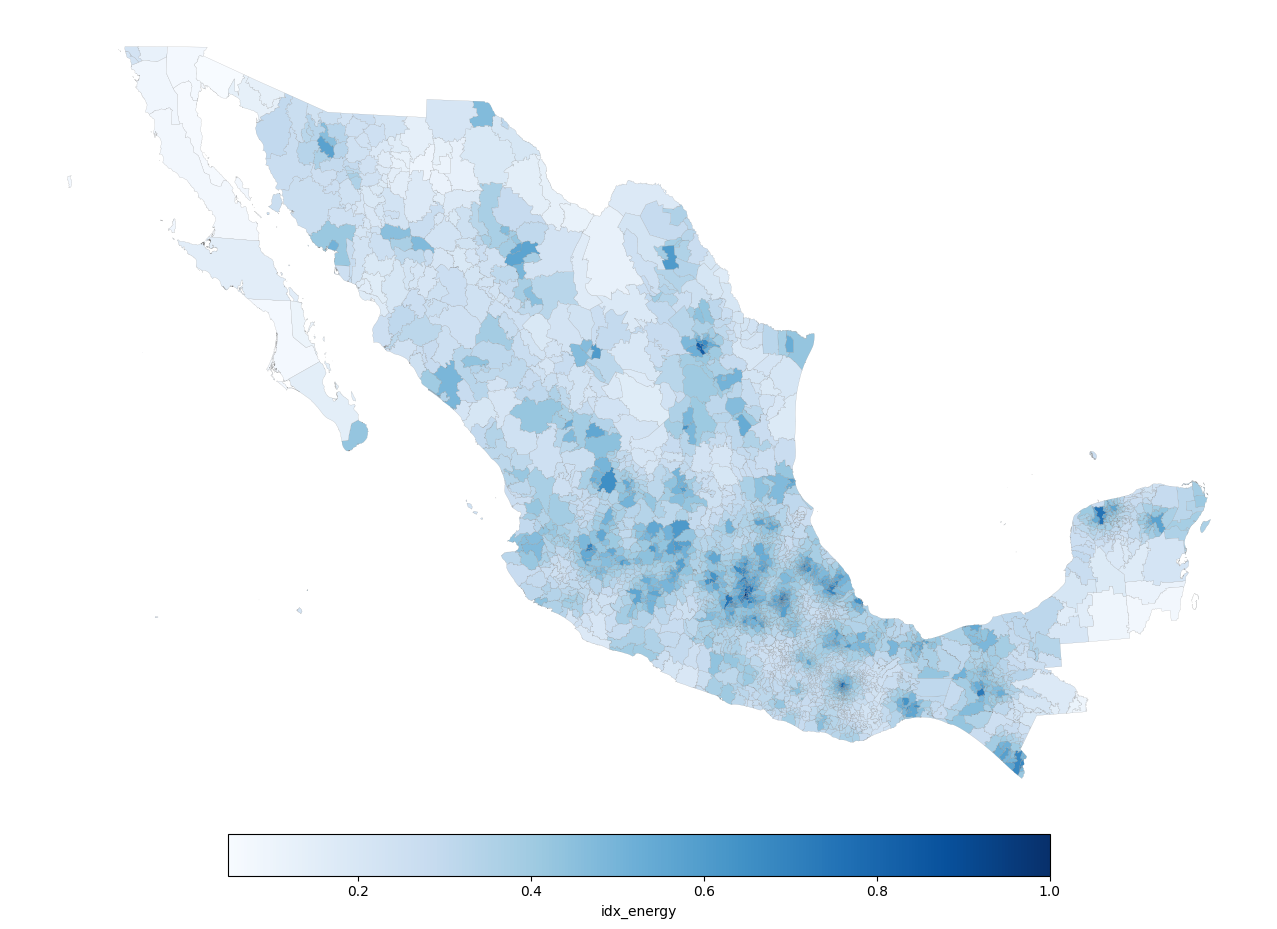

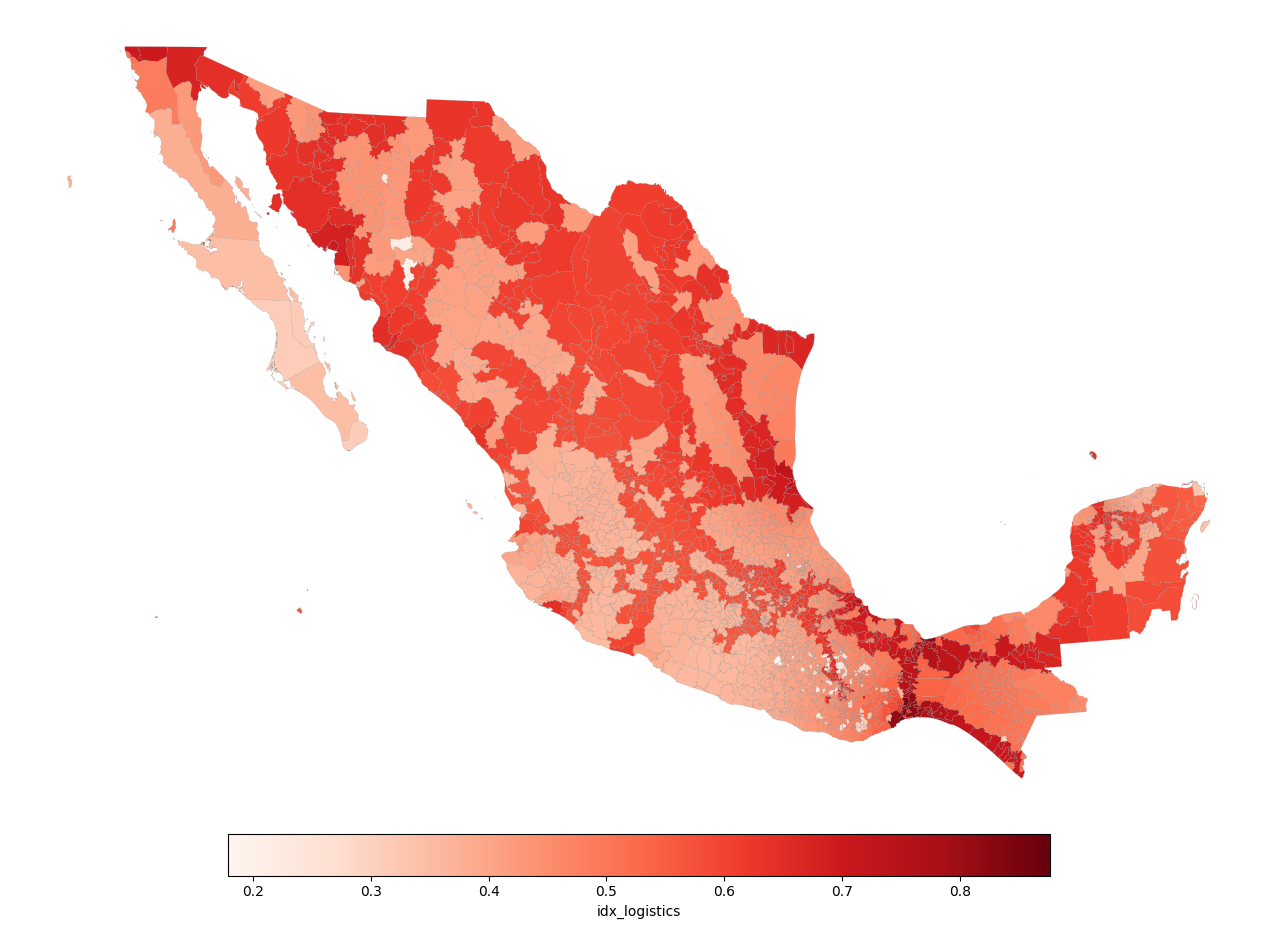

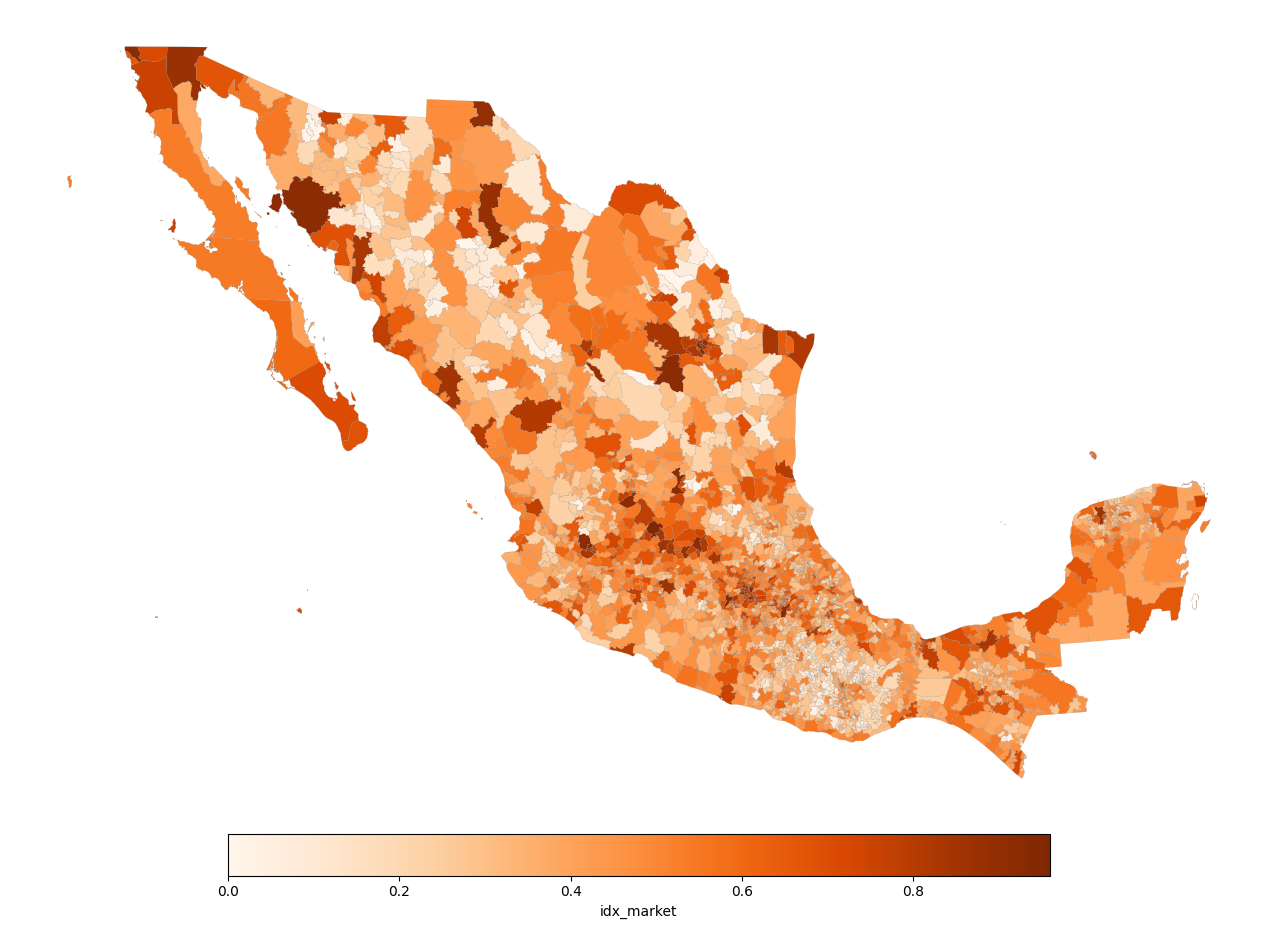

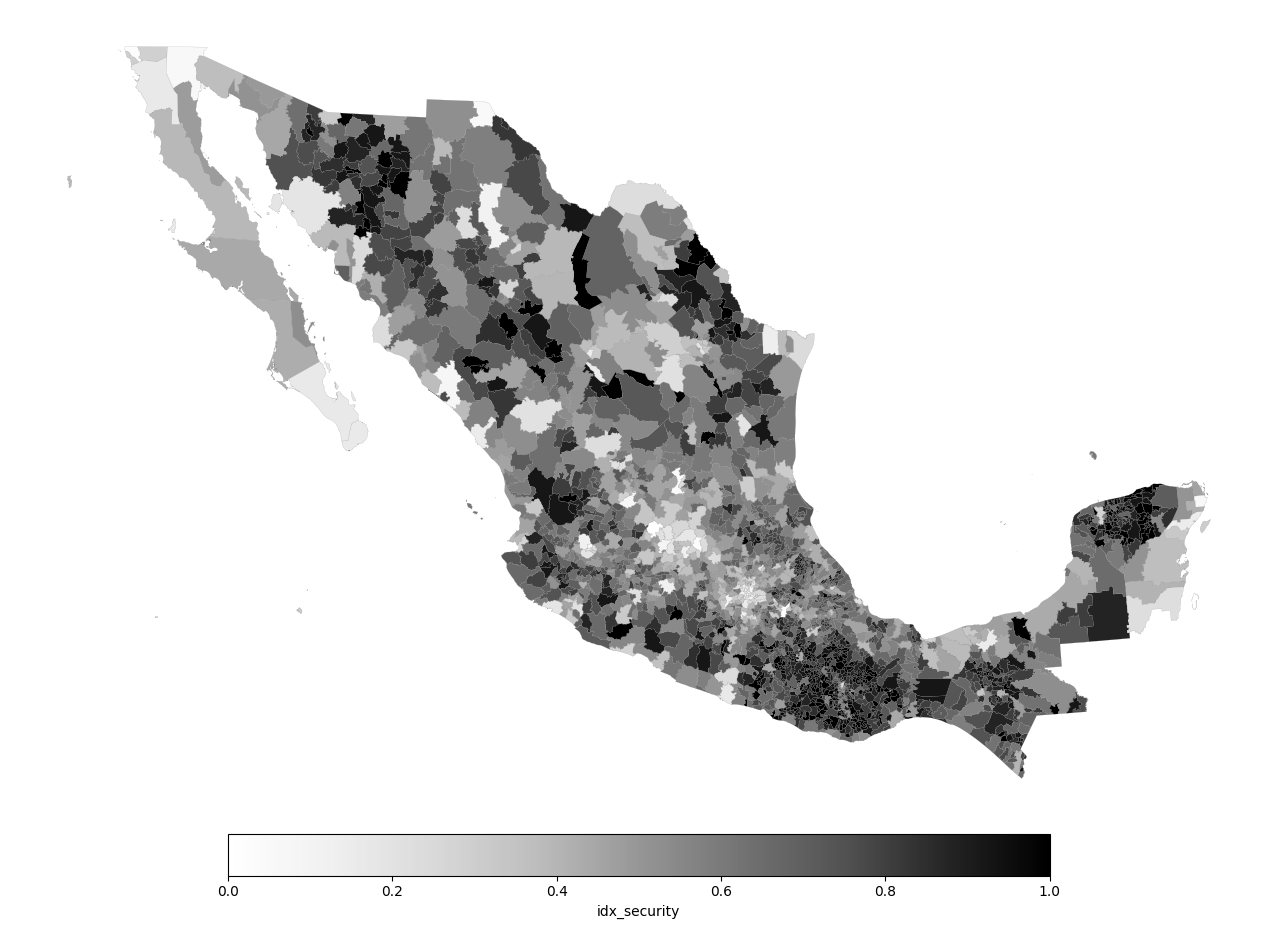

In [26]:
for column in plot_columns:
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    
    gdf.plot(
        column=column,
        cmap=colors[i],
        linewidth=0.1,
        edgecolor='grey',
        legend=True,
        legend_kwds={
            'label': column,
            'orientation': 'horizontal',
            'shrink': 0.6,
            'pad': 0.02
        },
        missing_kwds={'color': 'lightgrey', 'label': 'No data'},
        ax=ax
    )
    
    #ax.set_title('R.E.L.M.S. Index — Mexico', fontsize=16, fontweight='bold', pad=15)
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(RESULTS_DATA_DIR/f'maps/{column}_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    i += 1